# 01 — Data Understanding
### Track B — Customer Analytics cho E-Commerce | IT701220 Data Mining (Cao học)
**Người phụ trách:** Thành viên A — Data & Infrastructure Lead
**Bộ dữ liệu:** [Online Retail II — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/502/online+retail+ii)

---

**Input:** `data/raw/online_retail_II.xlsx` (2 sheet: "Year 2009-2010", "Year 2010-2011")

**Output:** Không xuất file dữ liệu ở notebook này (việc đó dành cho notebook `02_data_preparation.ipynb`).
Notebook này chỉ **khám phá và ghi nhận phát hiện** — mọi quyết định làm sạch sẽ được tổng kết ở cell cuối
cùng để dùng làm căn cứ viết `src/preprocessing/cleaning.py`.

**Mục lục:**
1. Đọc và gộp dữ liệu — tổng quan shape/dtypes/khoảng thời gian
2. Đếm số lượng giá trị duy nhất (Invoice, StockCode, Customer ID, Country)
3. Phân tích Missing Values
4. Phân tích dòng trùng lặp (Duplicate)
5. Phân tích Invoice huỷ (bắt đầu bằng "C")
6. Phân tích Quantity/Price âm hoặc bằng 0 — phát hiện bút toán điều chỉnh sổ sách
7. Phân tích StockCode không phải sản phẩm thật
8. So sánh Outlier: IQR vs Z-score
9. Kiểm tra Outlier Quantity cao — bán buôn hợp lệ hay lỗi nhập liệu?
10. Phân tích Country
11. Tổng kết quyết định làm sạch dữ liệu (căn cứ cho `cleaning.py`)


## 0. Chuẩn bị môi trường — import thư viện & load module dùng chung

In [ ]:
# Import các thư viện chuẩn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew

# Cho phép import module từ thư mục src/ dù notebook đang chạy từ thư mục con notebooks/
# (thêm thư mục gốc dự án vào sys.path)
import sys
from pathlib import Path

# Path.cwd() trả về thư mục đang chạy Jupyter - thường là thư mục gốc dự án
# hoặc thư mục notebooks/, nên ta thử cả 2 khả năng để chắc chắn tìm được thư mục gốc
thu_muc_hien_tai = Path.cwd()
if (thu_muc_hien_tai / "src").exists():
    PROJECT_ROOT_TAM = thu_muc_hien_tai
else:
    PROJECT_ROOT_TAM = thu_muc_hien_tai.parent

sys.path.insert(0, str(PROJECT_ROOT_TAM))

# Import các hàm dùng chung đã viết ở BƯỚC 1, BƯỚC 2
from src.utils.io import load_raw_excel, get_project_root, RAW_DATA_DIR, INTERIM_DATA_DIR
from src.utils.visualization import (
    set_plot_style,
    plot_histogram_boxplot,
    plot_missing_values,
    save_current_figure,
    PRIMARY_COLOR,
    SECONDARY_COLOR,
    ALERT_COLOR,
)

set_plot_style()

print(f"Thư mục gốc dự án : {get_project_root()}")
print(f"Thư mục dữ liệu thô: {RAW_DATA_DIR}")


Thư mục gốc dự án : /home/claude/project
Thư mục dữ liệu thô: /home/claude/project/data/raw


## 1. Đọc và gộp dữ liệu

Dữ liệu gốc gồm 2 sheet Excel: `Year 2009-2010` và `Year 2010-2011`. Ta gộp lại thành 1 DataFrame
duy nhất bằng hàm `load_raw_excel()` đã viết sẵn trong `src/utils/io.py`.

**Lưu ý quan trọng:** việc gộp 2 sheet PHẢI thực hiện ở bước này, TRƯỚC khi kiểm tra duplicate ở Mục 4 —
nếu kiểm tra duplicate riêng lẻ trên từng sheet, ta sẽ bỏ sót các dòng trùng lặp NẰM GIỮA 2 sheet.

In [ ]:
df = load_raw_excel()

print(f"Shape sau khi gộp 2 sheet : {df.shape[0]:,} dòng × {df.shape[1]} cột")
print(f"\nDanh sách cột: {list(df.columns)}")
print(f"\nKiểu dữ liệu từng cột:")
print(df.dtypes)


Shape sau khi gộp 2 sheet : 1,067,371 dòng × 9 cột

Danh sách cột: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Sheet']

Kiểu dữ liệu từng cột:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
Sheet                     str
dtype: object


In [ ]:
# Khoảng thời gian dữ liệu bao phủ
print(f"Ngày giao dịch sớm nhất : {df['InvoiceDate'].min()}")
print(f"Ngày giao dịch muộn nhất: {df['InvoiceDate'].max()}")
print(f"Tổng số ngày            : {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days:,} ngày")

df.head()


Ngày giao dịch sớm nhất : 2009-12-01 07:45:00
Ngày giao dịch muộn nhất: 2011-12-09 12:50:00
Tổng số ngày            : 738 ngày


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Year 2009-2010


**Nhận xét:** Dữ liệu trải dài khoảng 2 năm (01/12/2009 – 09/12/2011), đúng như mô tả trên trang UCI.
9 cột gồm 8 cột gốc (`Invoice, StockCode, Description, Quantity, InvoiceDate, Price, Customer ID, Country`)
và 1 cột `Sheet` được thêm vào để truy vết dòng dữ liệu đến từ sheet nào.

## 2. Đếm số lượng giá trị duy nhất (cardinality)

In [ ]:
bang_cardinality = pd.DataFrame({
    "Số giá trị duy nhất": [
        df["Invoice"].nunique(),
        df["StockCode"].nunique(),
        df["Customer ID"].nunique(),
        df["Country"].nunique(),
    ]
}, index=["Invoice", "StockCode", "Customer ID", "Country"])

bang_cardinality


,Số giá trị duy nhất
Invoice,53628
StockCode,5305
Customer ID,5942
Country,43


**Nhận xét:** Số Invoice duy nhất thể hiện tổng số hoá đơn (bao gồm cả hoá đơn huỷ, sẽ phân tích ở
Mục 5). Số Customer ID duy nhất là quy mô khách hàng thực tế — con số này sẽ là input cho pipeline
RFM/Clustering (Thành viên C) và Churn (Thành viên D).

## 3. Phân tích Missing Values

Kiểm tra tỷ lệ giá trị thiếu (NaN) theo từng cột. Dự kiến 2 cột có vấn đề: `Customer ID` (khá cao,
do nhiều đơn hàng không định danh khách — ví dụ mua tại quầy) và `Description` (thấp, có thể do lỗi
nhập liệu ở một số StockCode hiếm).

Đã lưu biểu đồ: /home/claude/project/reports/figures/01_missing_values.png


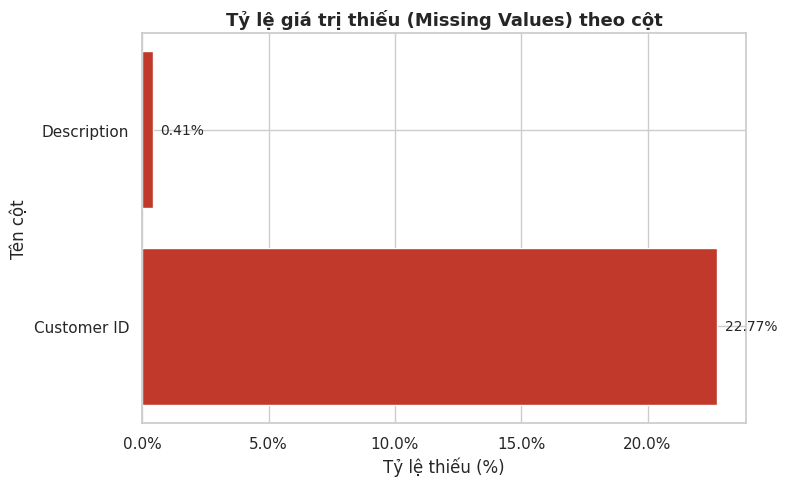

,missing_count,missing_pct
Customer ID,243007,22.77
Description,4382,0.41
Invoice,0,0.00
Quantity,0,0.00
StockCode,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00
Sheet,0,0.00


In [ ]:
bang_missing = plot_missing_values(df, save_as="01_missing_values.png")
bang_missing


In [ ]:
# Xuất bảng thống kê missing ra data/interim/ - đây là MINH CHỨNG cụ thể
# mà rubric Midterm §4.2 tiêu chí 2 yêu cầu (không chỉ mô tả bằng lời)
from src.utils.io import save_to_csv

save_to_csv(bang_missing.reset_index().rename(columns={"index": "column"}),
            INTERIM_DATA_DIR / "eda_summary_stats.csv")


Đã lưu file: /home/claude/project/data/interim/eda_summary_stats.csv  (số dòng: 9 | số cột: 3)


**Nhận xét:** `Customer ID` thiếu ở một tỷ lệ đáng kể — đây là các giao dịch KHÔNG xác định được
khách hàng cụ thể. Quyết định xử lý (xem Mục 11): giữ lại các dòng này cho pipeline MBA (không cần biết
ai mua), nhưng loại bỏ cho pipeline RFM/Churn (bắt buộc phải biết khách hàng là ai).

`Description` thiếu ở tỷ lệ rất nhỏ — thường đi kèm các StockCode bất thường sẽ được phân tích ở Mục 7.

## 4. Phân tích dòng trùng lặp (Duplicate)

**Lưu ý kỹ thuật quan trọng:** phải tính duplicate trên DataFrame ĐÃ GỘP cả 2 sheet (biến `df` ở đây),
KHÔNG tính riêng lẻ trên từng sheet rồi cộng lại — nếu làm sai thứ tự này, ta sẽ bỏ sót các dòng trùng
lặp nằm giữa ranh giới 2 sheet (ví dụ do file nguồn bị export lặp ở vài dòng cuối/đầu năm).

Cột `Sheet` (do ta tự thêm để đánh dấu nguồn) cần loại ra trước khi kiểm tra trùng lặp, vì nếu tính
luôn cột này, 2 dòng dữ liệu giống hệt nhau nhưng khác sheet sẽ KHÔNG bị coi là trùng lặp — sai với
bản chất dữ liệu gốc (vốn không có cột "Sheet").

In [ ]:
cac_cot_goc = [c for c in df.columns if c != "Sheet"]

so_dong_trung_lap = df.duplicated(subset=cac_cot_goc).sum()
ty_le_trung_lap = so_dong_trung_lap / len(df) * 100

print(f"Số dòng trùng lặp hoàn toàn (không tính cột Sheet): {so_dong_trung_lap:,} "
      f"({ty_le_trung_lap:.2f}% tổng dữ liệu)")

# Xem thử vài nhóm dòng trùng lặp cụ thể để hiểu bản chất
vi_du_trung_lap = df[df.duplicated(subset=cac_cot_goc, keep=False)].sort_values(cac_cot_goc)
vi_du_trung_lap.head(6)


Số dòng trùng lặp hoàn toàn (không tính cột Sheet): 34,335 (3.22% tổng dữ liệu)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sheet
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom,Year 2009-2010
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom,Year 2009-2010
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Year 2009-2010
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Year 2009-2010
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Year 2009-2010
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Year 2009-2010


**Nhận xét:** Tỷ lệ trùng lặp ở mức vài phần trăm — phổ biến với dữ liệu giao dịch bán lẻ xuất ra
từ hệ thống POS (có thể do nhân viên quét lại mã vạch, hoặc lỗi đồng bộ hệ thống khi export). Quyết định
xử lý: loại bỏ bằng `drop_duplicates()`, giữ lại 1 bản ghi duy nhất cho mỗi nhóm trùng lặp (xem Mục 11).

## 5. Phân tích Invoice huỷ (Invoice bắt đầu bằng "C")

Theo mô tả dataset UCI, các Invoice có mã bắt đầu bằng chữ **"C"** là hoá đơn HUỶ (cancellation) —
đi kèm `Quantity` âm, thể hiện việc trả hàng/huỷ đơn.

In [ ]:
df["Invoice_str"] = df["Invoice"].astype(str)
la_invoice_huy = df["Invoice_str"].str.startswith("C")

so_dong_huy = la_invoice_huy.sum()
so_invoice_huy = df.loc[la_invoice_huy, "Invoice_str"].nunique()
tong_so_invoice = df["Invoice_str"].nunique()

print(f"Số DÒNG thuộc invoice huỷ    : {so_dong_huy:,} ({so_dong_huy/len(df)*100:.2f}% tổng số dòng)")
print(f"Số INVOICE huỷ / tổng invoice: {so_invoice_huy:,} / {tong_so_invoice:,} "
      f"({so_invoice_huy/tong_so_invoice*100:.2f}%)")

df[la_invoice_huy][["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID"]].head(5)


Số DÒNG thuộc invoice huỷ    : 19,494 (1.83% tổng số dòng)
Số INVOICE huỷ / tổng invoice: 8,292 / 53,628 (15.46%)


,Invoice,StockCode,Description,Quantity,Price,Customer ID
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2.95,16321.0
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,1.65,16321.0
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,4.25,16321.0
181,C489449,21896,POTTING SHED TWINE,-6,2.10,16321.0
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2.95,16321.0


**Nhận xét:** Một tỷ lệ đáng kể số HOÁ ĐƠN (không phải số dòng) là hoá đơn huỷ — đây là hiện tượng
tự nhiên trong bán lẻ (khách trả hàng, đơn lỗi...). Quyết định xử lý: loại các dòng này khỏi
`transactions_clean.csv` cho pipeline MBA và RFM/Churn, vì đây không phải giao dịch mua thành công.

## 6. Phân tích Quantity và Price âm hoặc bằng 0

**Phát hiện quan trọng:** không phải MỌI dòng có `Quantity` âm đều là invoice huỷ. Có một nhóm nhỏ các
dòng `Quantity` âm nhưng KHÔNG thuộc invoice huỷ (Invoice không bắt đầu bằng "C") — đây là các
**bút toán điều chỉnh sổ sách nội bộ** (ví dụ hàng thất lạc, hư hỏng), thường có `Description` ghi các
từ như "lost", "damages", "thrown away", "found"... và luôn đi kèm `Price = 0` và thiếu `Customer ID`.

In [ ]:
# 6.1 Quantity âm
so_dong_qty_am = (df["Quantity"] < 0).sum()
print(f"Số dòng Quantity âm: {so_dong_qty_am:,} ({so_dong_qty_am/len(df)*100:.2f}%)")

qty_am = df[df["Quantity"] < 0]
qty_am_khong_phai_huy = qty_am[~qty_am["Invoice_str"].str.startswith("C")]

print(f"Trong đó, thuộc invoice huỷ         : {(qty_am['Invoice_str'].str.startswith('C')).sum():,}")
print(f"Quantity âm nhưng KHÔNG phải invoice huỷ: {len(qty_am_khong_phai_huy):,}")


Số dòng Quantity âm: 22,950 (2.15%)
Trong đó, thuộc invoice huỷ         : 19,493
Quantity âm nhưng KHÔNG phải invoice huỷ: 3,457


In [ ]:
# Kiểm tra đặc điểm của nhóm "Quantity âm không phải invoice huỷ"
print("Đặc điểm nhóm này (kỳ vọng: Price luôn = 0, Customer ID luôn thiếu):")
print(f"  - Tỷ lệ Price = 0        : {(qty_am_khong_phai_huy['Price'] == 0).mean()*100:.1f}%")
print(f"  - Tỷ lệ thiếu Customer ID: {qty_am_khong_phai_huy['Customer ID'].isnull().mean()*100:.1f}%")

qty_am_khong_phai_huy[["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID"]].head(10)


Đặc điểm nhóm này (kỳ vọng: Price luôn = 0, Customer ID luôn thiếu):
  - Tỷ lệ Price = 0        : 100.0%
  - Tỷ lệ thiếu Customer ID: 100.0%


,Invoice,StockCode,Description,Quantity,Price,Customer ID
263,489464,21733,85123a mixed,-96,0.0,NaN
283,489463,71477,short,-240,0.0,NaN
284,489467,85123A,21733 mixed,-192,0.0,NaN
470,489521,21646,NaN,-50,0.0,NaN
3114,489655,20683,NaN,-44,0.0,NaN
3162,489660,35956,lost,-1043,0.0,NaN
3168,489663,35605A,damages,-117,0.0,NaN
4296,489806,18010,NaN,-770,0.0,NaN
4538,489820,21133,invcd as 84879?,-720,0.0,NaN
4566,489821,85049G,NaN,-240,0.0,NaN


In [ ]:
# 6.2 Rà thêm các Description chứa từ khoá liên quan đến hư hỏng/thất lạc/điều chỉnh sổ sách
# (mở rộng hơn "lost"/"damages" - bổ sung thêm các từ khoá đã phát hiện thực tế trên dataset)
tu_khoa_dieu_chinh = ["LOST", "DAMAGE", "DAMAGES", "FOUND", "MISSING", "THROWN AWAY",
                      "WRONG", "SMASHED", "CRUSHED", "MOULDY", "RUSTY", "CHECK", "ADJUST"]

desc_upper = df["Description"].astype(str).str.upper()
mat_na_dieu_chinh = desc_upper.str.contains("|".join(tu_khoa_dieu_chinh), na=False, regex=True)

print("Số dòng có Description chứa từ khoá liên quan đến điều chỉnh sổ sách:")
for tu_khoa in tu_khoa_dieu_chinh:
    dem = desc_upper.str.contains(tu_khoa, na=False, regex=False).sum()
    if dem > 0:
        print(f"  '{tu_khoa}': {dem:,} dòng")

print(f"\nTổng cộng (không trùng lặp): {mat_na_dieu_chinh.sum():,} dòng")


Số dòng có Description chứa từ khoá liên quan đến điều chỉnh sổ sách:
  'LOST': 11 dòng


  'DAMAGE': 220 dòng
  'DAMAGES': 110 dòng


  'FOUND': 43 dòng
  'MISSING': 41 dòng


  'THROWN AWAY': 22 dòng
  'WRONG': 24 dòng


  'SMASHED': 10 dòng
  'CRUSHED': 9 dòng


  'MOULDY': 5 dòng
  'RUSTY': 12 dòng


  'CHECK': 898 dòng
  'ADJUST': 110 dòng

Tổng cộng (không trùng lặp): 1,397 dòng


In [ ]:
# 6.3 Trường hợp đặc biệt: "Adjust bad debt" - bút toán xoá nợ xấu kế toán
# Invoice bắt đầu bằng "A" (khác với "C" của invoice huỷ), StockCode = "B"
la_invoice_dieu_chinh_no = df["Invoice_str"].str.startswith("A")
if la_invoice_dieu_chinh_no.sum() > 0:
    print(f"Phát hiện {la_invoice_dieu_chinh_no.sum()} dòng 'Adjust bad debt' "
          f"(Invoice bắt đầu bằng 'A') - đây KHÔNG phải giao dịch bán hàng, cần loại bỏ:")
    display_cols = ["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID"]
    print(df[la_invoice_dieu_chinh_no][display_cols].to_string(index=False))


Phát hiện 6 dòng 'Adjust bad debt' (Invoice bắt đầu bằng 'A') - đây KHÔNG phải giao dịch bán hàng, cần loại bỏ:
Invoice StockCode     Description  Quantity     Price  Customer ID
A506401         B Adjust bad debt         1 -53594.36          NaN
A516228         B Adjust bad debt         1 -44031.79          NaN
A528059         B Adjust bad debt         1 -38925.87          NaN
A563185         B Adjust bad debt         1  11062.06          NaN
A563186         B Adjust bad debt         1 -11062.06          NaN
A563187         B Adjust bad debt         1 -11062.06          NaN


In [ ]:
# 6.4 Price = 0 (không chỉ riêng nhóm điều chỉnh sổ sách ở trên)
so_dong_price_0 = (df["Price"] == 0).sum()
print(f"Tổng số dòng Price = 0: {so_dong_price_0:,} ({so_dong_price_0/len(df)*100:.2f}%)")
print("(Bao gồm cả các dòng điều chỉnh sổ sách đã phát hiện ở trên, và có thể có thêm dòng khác)")


Tổng số dòng Price = 0: 6,202 (0.58%)
(Bao gồm cả các dòng điều chỉnh sổ sách đã phát hiện ở trên, và có thể có thêm dòng khác)


**Nhận xét tổng hợp Mục 6:** Có 2 nhóm dữ liệu KHÔNG phải giao dịch mua bán thật cần loại bỏ:
1. Quantity âm không thuộc invoice huỷ (bút toán điều chỉnh kho — mất mát, hư hỏng)
2. Invoice bắt đầu bằng "A" (bút toán xoá nợ xấu kế toán)

Cả 2 nhóm này nếu không loại bỏ sẽ làm méo thống kê doanh thu (TotalPrice) và có thể ảnh hưởng nghiêm
trọng đến outlier detection ở Mục 8 (do các giá trị Price cực âm). Quyết định: loại khỏi
`transactions_clean.csv` (xem Mục 11).

## 7. Phân tích StockCode không phải sản phẩm thật

Một số `StockCode` không đại diện cho sản phẩm vật lý mà là các khoản phí/phụ phí/nghiệp vụ kế toán:
`POST` (phí bưu điện), `DOT` (phí), `M`/`Manual` (thủ công), `D` (chiết khấu/Discount),
`BANK CHARGES` (phí ngân hàng), `CRUK` (từ thiện Cancer Research UK), `AMAZONFEE` (phí Amazon),
`S` (mẫu thử/Samples), `C2` (phí vận chuyển/Carriage), `PADS`, `ADJUST` (điều chỉnh), và
`TEST001`/`TEST002` (dữ liệu test nội bộ).

In [ ]:
ma_phi_san_pham = ["POST", "DOT", "M", "D", "BANK CHARGES", "CRUK", "AMAZONFEE",
                   "S", "C2", "PADS", "ADJUST", "TEST001", "TEST002"]

print(f"{'StockCode':<15}{'Số dòng':>12}   Ví dụ Description")
print("-" * 70)
tong_dong_phi_san_pham = 0
for ma in ma_phi_san_pham:
    khop = df[df["StockCode"].astype(str).str.upper() == ma]
    if len(khop) > 0:
        tong_dong_phi_san_pham += len(khop)
        vi_du_desc = khop["Description"].mode()
        vi_du_desc = vi_du_desc.iloc[0] if not vi_du_desc.empty else "N/A"
        print(f"{ma:<15}{len(khop):>12,}   {vi_du_desc}")

print("-" * 70)
print(f"{'TỔNG CỘNG':<15}{tong_dong_phi_san_pham:>12,}  "
      f"({tong_dong_phi_san_pham/len(df)*100:.2f}% tổng dữ liệu)")


StockCode           Số dòng   Ví dụ Description
----------------------------------------------------------------------


POST                  2,122   POSTAGE


DOT                   1,446   DOTCOM POSTAGE


M                     1,426   Manual
D                       177   Discount


BANK CHARGES            102   Bank Charges


...

C2                      282   CARRIAGE


PADS                     19   PADS TO MATCH ALL CUSHIONS


ADJUST                   67   Adjustment by john on 26/01/2010 16


TEST001                  15   This is a test product.


TEST002                   2   This is a test product.
----------------------------------------------------------------------
TỔNG CỘNG             5,821  (0.55% tổng dữ liệu)


In [ ]:
# Ảnh hưởng đến doanh thu nếu loại các mã này (chỉ tính dòng có Quantity, Price dương)
df["TotalPrice_tam"] = df["Quantity"] * df["Price"]

mat_na_phi_san_pham = df["StockCode"].astype(str).str.upper().isin(ma_phi_san_pham)
doanh_thu_phi_san_pham = df.loc[mat_na_phi_san_pham & (df["TotalPrice_tam"] > 0), "TotalPrice_tam"].sum()
doanh_thu_tong = df.loc[df["TotalPrice_tam"] > 0, "TotalPrice_tam"].sum()

print(f"Doanh thu (dương) từ các mã phi sản phẩm: £{doanh_thu_phi_san_pham:,.0f}")
print(f"Doanh thu (dương) tổng toàn bộ dữ liệu  : £{doanh_thu_tong:,.0f}")
print(f"Tỷ lệ: {doanh_thu_phi_san_pham/doanh_thu_tong*100:.2f}% doanh thu ghi nhận đến từ phí/phi sản phẩm")

df.drop(columns=["TotalPrice_tam"], inplace=True)  # cột tạm, xoá sau khi dùng xong


Doanh thu (dương) từ các mã phi sản phẩm: £849,238
Doanh thu (dương) tổng toàn bộ dữ liệu  : £20,972,968
Tỷ lệ: 4.05% doanh thu ghi nhận đến từ phí/phi sản phẩm


**Nhận xét:** Các mã phi sản phẩm chiếm tỷ lệ nhỏ về số dòng nhưng cần loại bỏ triệt để trước khi
đưa vào MBA (nếu không, luật kết hợp sẽ sinh ra các luật vô nghĩa kiểu "mua sản phẩm A thường đi kèm
phí bưu điện") và trước khi tính Monetary cho RFM (nếu không, phí bưu điện sẽ bị tính nhầm là doanh thu
sản phẩm).

## 8. So sánh Outlier: IQR vs Z-score

**Điểm cần lưu ý:** `Quantity` có độ lệch (skewness) rất cao do một số giao dịch bán buôn với số lượng
cực lớn. Ta sẽ chứng minh bằng số liệu cụ thể rằng: nếu dùng Z-score trực tiếp trên dữ liệu gốc (chưa
transform), phương pháp này cho kết quả SAI LỆCH (bắt được quá ít outlier) so với IQR — vì độ lệch chuẩn
bị vài giá trị cực lớn kéo giãn ra. Cần `log1p`-transform trước khi tính Z-score để có kết quả hợp lý hơn.

Ta chỉ xét trên các dòng có `Quantity > 0` và `Price > 0` (tức giao dịch mua thành công, đã loại invoice
huỷ và các dòng bất thường) để phân tích outlier có ý nghĩa thực tế.

In [ ]:
du_lieu_duong = df[(df["Quantity"] > 0) & (df["Price"] > 0)].copy()

print(f"Skewness của Quantity (dữ liệu gốc, dương)     : {skew(du_lieu_duong['Quantity']):.2f}")
print(f"Skewness của log1p(Quantity)                    : {skew(np.log1p(du_lieu_duong['Quantity'])):.2f}")
print("(Skewness càng gần 0 càng đối xứng; giá trị lớn cho thấy đuôi phân phối rất dài)")


Skewness của Quantity (dữ liệu gốc, dương)     : 459.99
Skewness của log1p(Quantity)                    : 1.06
(Skewness càng gần 0 càng đối xứng; giá trị lớn cho thấy đuôi phân phối rất dài)


In [ ]:
# --- Phương pháp 1: IQR ---
Q1, Q3 = du_lieu_duong["Quantity"].quantile([0.25, 0.75])
IQR = Q3 - Q1
can_duoi, can_tren = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outlier_iqr = (du_lieu_duong["Quantity"] < can_duoi) | (du_lieu_duong["Quantity"] > can_tren)

print(f"[IQR] Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}, cận=({can_duoi:.1f}, {can_tren:.1f})")
print(f"[IQR] Số outlier phát hiện: {outlier_iqr.sum():,} ({outlier_iqr.sum()/len(du_lieu_duong)*100:.2f}%)")

# --- Phương pháp 2: Z-score TRÊN DỮ LIỆU GỐC (chưa transform) ---
trung_binh, do_lech_chuan = du_lieu_duong["Quantity"].mean(), du_lieu_duong["Quantity"].std()
z_goc = (du_lieu_duong["Quantity"] - trung_binh) / do_lech_chuan
outlier_z_goc = z_goc.abs() > 3

print(f"\n[Z-score, dữ liệu GỐC] Số outlier phát hiện: {outlier_z_goc.sum():,} "
      f"({outlier_z_goc.sum()/len(du_lieu_duong)*100:.2f}%)")

# --- Phương pháp 3: Z-score SAU log1p-transform ---
log_qty = np.log1p(du_lieu_duong["Quantity"])
tb_log, sd_log = log_qty.mean(), log_qty.std()
z_log = (log_qty - tb_log) / sd_log
outlier_z_log = z_log.abs() > 3

print(f"[Z-score, SAU log1p] Số outlier phát hiện: {outlier_z_log.sum():,} "
      f"({outlier_z_log.sum()/len(du_lieu_duong)*100:.2f}%)")


[IQR] Q1=1.0, Q3=10.0, IQR=9.0, cận=(-12.5, 23.5)
[IQR] Số outlier phát hiện: 111,341 (10.69%)

[Z-score, dữ liệu GỐC] Số outlier phát hiện: 1,590 (0.15%)
[Z-score, SAU log1p] Số outlier phát hiện: 9,939 (0.95%)


In [ ]:
bang_so_sanh_outlier = pd.DataFrame({
    "Phương pháp": ["IQR", "Z-score (dữ liệu gốc)", "Z-score (sau log1p)"],
    "Số outlier": [outlier_iqr.sum(), outlier_z_goc.sum(), outlier_z_log.sum()],
    "Tỷ lệ (%)": [outlier_iqr.mean()*100, outlier_z_goc.mean()*100, outlier_z_log.mean()*100],
})
bang_so_sanh_outlier


,Phương pháp,Số outlier,Tỷ lệ (%)
0,IQR,111341,10.688692
1,Z-score (dữ liệu gốc),1590,0.152639
2,Z-score (sau log1p),9939,0.954140


Đã lưu biểu đồ: /home/claude/project/reports/figures/02_quantity_hist_box.png


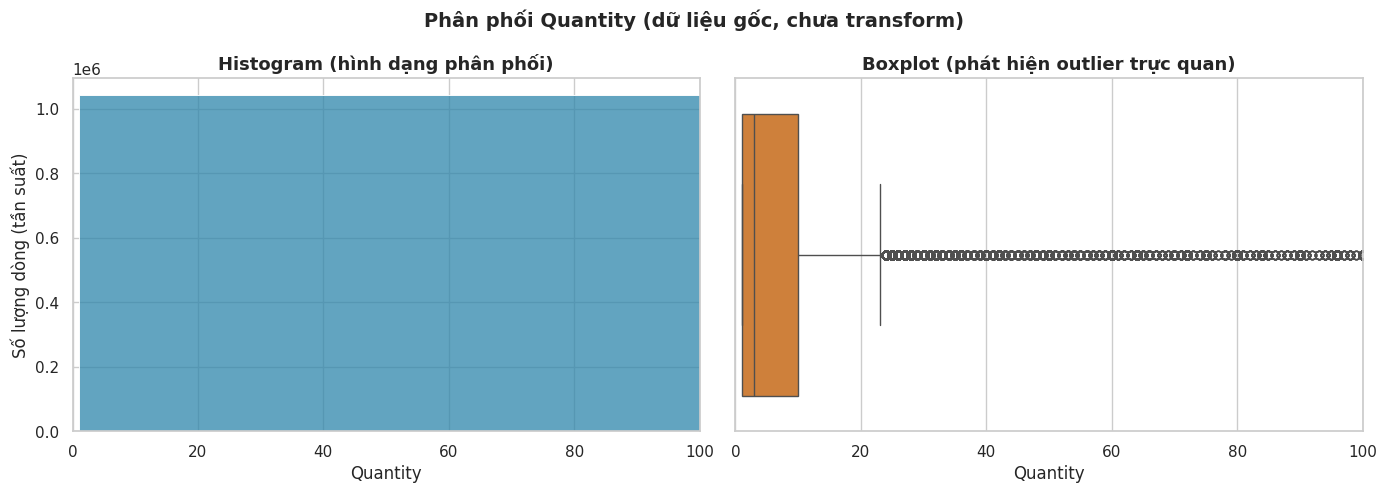

In [ ]:
plot_histogram_boxplot(du_lieu_duong, "Quantity",
                      title="Phân phối Quantity (dữ liệu gốc, chưa transform)",
                      xlim=(0, du_lieu_duong["Quantity"].quantile(0.99)),
                      save_as="02_quantity_hist_box.png")


**Nhận xét:** Đúng như dự đoán, Z-score trên dữ liệu GỐC cho kết quả khác biệt RẤT LỚN so với IQR
— vì độ lệch chuẩn (std) bị vài giá trị Quantity cực lớn (bán buôn) kéo giãn ra, khiến hầu hết các điểm
"nhìn có vẻ outlier theo IQR" lại có |Z| < 3. Sau khi log1p-transform, Z-score cho kết quả hợp lý và
gần với IQR hơn. **Kết luận: cần log-transform Quantity trước khi áp dụng Z-score**, đây là căn cứ kỹ
thuật cho hàm xử lý outlier trong `cleaning.py`.

## 9. Outlier Quantity cao — bán buôn hợp lệ hay lỗi nhập liệu?

Giả thuyết: nếu nhóm Quantity cao có `Price` trung vị THẤP HƠN Price trung vị chung, đây là dấu hiệu
ủng hộ giả thuyết "bán buôn hợp lệ, giá ưu đãi cho số lượng lớn" — không phải lỗi nhập liệu.

In [ ]:
nguong_qty_cao = du_lieu_duong["Quantity"].quantile(0.99)  # top 1% Quantity cao nhất
nhom_qty_cao = du_lieu_duong[du_lieu_duong["Quantity"] >= nguong_qty_cao]

print(f"Ngưỡng Quantity cao (percentile 99): {nguong_qty_cao:.0f}")
print(f"Số dòng thuộc nhóm Quantity cao     : {len(nhom_qty_cao):,}")
print(f"\nPrice trung vị của nhóm Quantity cao : £{nhom_qty_cao['Price'].median():.2f}")
print(f"Price trung vị của TOÀN BỘ dữ liệu   : £{du_lieu_duong['Price'].median():.2f}")

nhom_qty_cao.nlargest(5, "Quantity")[["Invoice", "StockCode", "Description",
                                        "Quantity", "Price", "Customer ID", "Country"]]


Ngưỡng Quantity cao (percentile 99): 100
Số dòng thuộc nhóm Quantity cao     : 13,524

Price trung vị của nhóm Quantity cao : £1.06
Price trung vị của TOÀN BỘ dữ liệu   : £2.10


,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0,United Kingdom
587080,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0,United Kingdom
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,0.10,13902.0,Denmark
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,0.10,13902.0,Denmark
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,0.10,13902.0,Denmark


**Nhận xét:** Price trung vị của nhóm Quantity cao thấp hơn đáng kể so với Price trung vị chung —
đây là bằng chứng ủng hộ giả thuyết các đơn hàng Quantity lớn là **bán buôn hợp lệ** (giá đơn vị rẻ hơn
khi mua số lượng lớn), KHÔNG phải lỗi nhập liệu. Quyết định: KHÔNG xoá các dòng này khi xử lý outlier —
chỉ dùng ngưỡng outlier để NHẬN DIỆN và ghi chú, không tự động loại bỏ toàn bộ (xem Mục 11).

## 10. Phân tích Country

In [ ]:
phan_bo_quoc_gia = df["Country"].value_counts()
ty_le_uk = phan_bo_quoc_gia.get("United Kingdom", 0) / len(df) * 100

print(f"Số quốc gia khác nhau: {df['Country'].nunique()}")
print(f"Tỷ lệ United Kingdom : {ty_le_uk:.2f}%")
print(f"\nTop 10 quốc gia có nhiều giao dịch nhất:")
phan_bo_quoc_gia.head(10)


Số quốc gia khác nhau: 43
Tỷ lệ United Kingdom : 91.94%

Top 10 quốc gia có nhiều giao dịch nhất:


Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64

In [ ]:
# Mối liên hệ giữa Country và tỷ lệ thiếu Customer ID
ty_le_thieu_theo_qg = (
    df.groupby("Country")["Customer ID"]
    .apply(lambda x: x.isnull().mean() * 100)
    .sort_values(ascending=False)
)

print("Top 10 quốc gia có tỷ lệ thiếu Customer ID CAO nhất:")
print(ty_le_thieu_theo_qg.head(10))
print(f"\nRiêng United Kingdom: {ty_le_thieu_theo_qg.get('United Kingdom', float('nan')):.2f}% thiếu Customer ID")


Top 10 quốc gia có tỷ lệ thiếu Customer ID CAO nhất:
Country
Bermuda                 100.000000
Hong Kong               100.000000
Bahrain                  53.174603
Unspecified              30.687831
RSA                      27.218935
United Kingdom           24.459560
United Arab Emirates     22.800000
Lebanon                  22.413793
Israel                   12.668464
EIRE                      9.352961
Name: Customer ID, dtype: float64

Riêng United Kingdom: 24.46% thiếu Customer ID


Đã lưu biểu đồ: /home/claude/project/reports/figures/03_top10_country.png


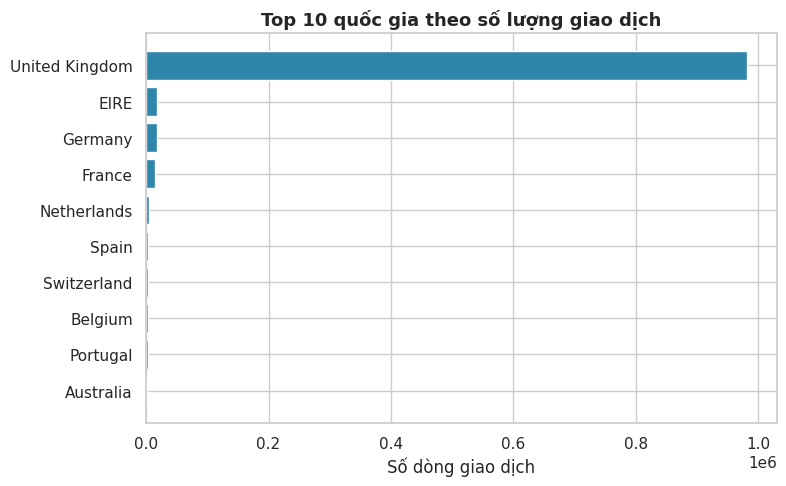

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
top10_qg = phan_bo_quoc_gia.head(10)
ax.barh(top10_qg.index[::-1], top10_qg.values[::-1], color=PRIMARY_COLOR)
ax.set_title("Top 10 quốc gia theo số lượng giao dịch")
ax.set_xlabel("Số dòng giao dịch")
plt.tight_layout()
save_current_figure("03_top10_country.png")
plt.show()


**Nhận xét:** Dữ liệu tập trung áp đảo vào United Kingdom — đây là thị trường chủ lực của doanh
nghiệp. Điều này cần lưu ý khi phân tích MBA/RFM/Churn: kết quả sẽ phần lớn phản ánh hành vi khách hàng
UK, các quốc gia khác có quá ít dữ liệu để phân tích tách biệt một cách đáng tin cậy.

## 11. Tổng kết quyết định làm sạch dữ liệu

Đây là bảng tổng kết TẤT CẢ quyết định làm sạch sẽ áp dụng ở `src/preprocessing/cleaning.py` và
notebook `02_data_preparation.ipynb` — dựa trên toàn bộ phát hiện ở các mục trên. Bảng này vừa là tài
liệu tham khảo khi viết code, vừa là bằng chứng tư duy logic khi trình bày Midterm.

| # | Vấn đề phát hiện | Quyết định xử lý | Áp dụng cho |
|---|---|---|---|
| 1 | Duplicate hoàn toàn (~vài % dữ liệu) | Loại bỏ bằng `drop_duplicates()` | Toàn bộ pipeline |
| 2 | Invoice huỷ (bắt đầu "C") | Loại bỏ toàn bộ dòng | Toàn bộ pipeline |
| 3 | Invoice điều chỉnh nợ xấu (bắt đầu "A") | Loại bỏ toàn bộ dòng | Toàn bộ pipeline |
| 4 | Quantity âm không phải invoice huỷ (điều chỉnh kho) | Loại bỏ toàn bộ dòng | Toàn bộ pipeline |
| 5 | StockCode phi sản phẩm (POST, DOT, M, D, BANK CHARGES...) | Loại bỏ toàn bộ dòng | Toàn bộ pipeline |
| 6 | Outlier Quantity/Price theo IQR | Ghi nhận, KHÔNG xoá tự động (đã xác nhận là bán buôn hợp lệ ở Mục 9) | Cân nhắc riêng khi cần |
| 7 | Customer ID thiếu | **Giữ lại** cho MBA (không cần biết ai mua) — **Loại bỏ** cho RFM/Churn | Tách nhánh theo pipeline |
| 8 | Skewness cao ở Quantity | Log-transform (`log1p`) trước khi tính Z-score hoặc đưa vào clustering | RFM/Clustering (Thành viên C) |

**Thứ tự áp dụng khuyến nghị trong `cleaning.py`:** loại invoice huỷ → loại invoice điều chỉnh nợ xấu →
loại Quantity âm bất thường → loại StockCode phi sản phẩm → loại duplicate → (tuỳ nhánh) loại thiếu
Customer ID.

Notebook tiếp theo: **`02_data_preparation.ipynb`** sẽ gọi lại các hàm trong `cleaning.py` theo đúng thứ
tự trên và xuất ra 3 file: `transactions_clean.csv`, `customer_rfm.csv`, `customer_churn_features.csv`.